In [9]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
%matplotlib inline


In [2]:
words=open('names.txt','r').read().splitlines()
print(len(words))
print(max(len(w)for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
vocab_size=len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
block_size=3
def build_dataset(words):  
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])  

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
def cmp(s,dt,t):
    ex=torch.all(dt==t.grad).item()
    app=torch.allclose(dt,t.grad)
    maxdiff=(dt-t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')


In [6]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BN params
bngain=torch.randn((1,n_hidden))*0.1+1 # 均值1 方差0.1
bnbias=torch.randn((1,n_hidden))*0.1
parameters=[C,W1,b1,W2,b2,bngain,bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

4137


In [7]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [14]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
bnmeani=1/n*hprebn.sum(0,keepdim=True)
bndiff=hprebn-bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer

# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values

norm_logits = logits - logit_maxes # subtract max for numerical stability
counts=norm_logits.exp()
counts_sum=counts.sum(1,keepdim=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss



tensor(3.3468, grad_fn=<NegBackward0>)

In [16]:
# exercise 1 :backprop through the whole thing mannually

dlogprobs=torch.zeros_like(logprobs)
dlogprobs[range(n),Yb]=-1.0/n
dprobs=(1/probs)*dlogprobs
dcounts_sum_inv=(counts*dprobs).sum(1,keepdim=True)
dcounts_sum=(-counts_sum_inv**2)*dcounts_sum_inv       # **2 not **-2 !!
dcounts=counts_sum_inv*dprobs + dcounts_sum             # must add counts_sum path!
dnorm_logits=counts*dcounts
dlogits=dnorm_logits.clone()
dlogit_maxes=(-dnorm_logits).sum(1,keepdim=True)
dlogits+=F.one_hot(logits.max(1).indices,num_classes=logits.shape[1])*dlogit_maxes
dh=dlogits@W2.T
db2=dlogits.sum(0)
dW2=h.T@dlogits
dhpreact=(1-h**2)*dh
dbngain=(bnraw*dhpreact).sum(0,keepdim=True)
dbnraw=bngain*dhpreact
dbnbias=dhpreact.sum(0,keepdim=True)

dbndiff=bnvar_inv*dbnraw
#bnvar_inv = (bnvar + 1e-5)**-0.5
#标准差倒数
dbnvar_inv=(bndiff*dbnraw).sum(0,keepdim=True)
#方差
dbnvar=(-0.5*(bnvar+1e-5)**-1.5)*dbnvar_inv
# 方差=1/n(值-均值)^2
dbndiff2=(1/(n-1))*torch.ones_like(bndiff)*dbnvar
dbndiff+=2*bndiff*dbndiff2
dhprebn=dbndiff.clone()
dbnmeani=(-dbndiff).sum(0)
dhprebn+=1/n*torch.ones_like(hprebn)*dbnmeani

dembcat=dhprebn@W1.T
dW1=embcat.T@dhprebn
db1=dhprebn.sum(0)
demb=dembcat.view(emb.shape)

dC=torch.zeros_like(C)
for j in range(Xb.shape[0]):
    for k in range(Xb.shape[1]):
        ix=Xb[j,k]
        dC[ix]+=demb[j,k]

cmp('logprobs',dlogprobs,logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)


logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: False | approximate: True  | maxdiff: 4.656612873077393e-10
counts          | exact: False | approximate: True  | maxdiff: 3.725290298461914e-09
norm_logits     | exact: False | approximate: True  | maxdiff: 3.725290298461914e-09
logit_maxes     | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
logits          | exact: False | approximate: True  | maxdiff: 6.984919309616089e-09
h               | exact: False | approximate: True  | maxdiff: 2.3283064365386963e-09
W2              | exact: False | approximate: True  | maxdiff: 1.1175870895385742e-08
b2              | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
hpreact         | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09
bngain          | exact: False |

In [17]:
loss_fast=F.cross_entropy(logits,Yb)
print(loss_fast.item(),'diff:',(loss_fast-loss).item())

3.346837282180786 diff: 0.0


In [18]:
dlogits=F.softmax(logits,1)
dlogits[range(n),Yb]-=1
dlogits/=n
cmp('logits',dlogits,logits)

logits          | exact: False | approximate: True  | maxdiff: 6.984919309616089e-09


In [19]:
logits.shape,Yb.shape

(torch.Size([32, 27]), torch.Size([32]))

In [23]:
F.softmax(logits,1)[0]

tensor([0.0629, 0.0920, 0.0187, 0.0481, 0.0183, 0.0836, 0.0248, 0.0376, 0.0186,
        0.0311, 0.0342, 0.0371, 0.0386, 0.0288, 0.0315, 0.0148, 0.0095, 0.0193,
        0.0172, 0.0585, 0.0480, 0.0207, 0.0243, 0.0727, 0.0628, 0.0242, 0.0221],
       grad_fn=<SelectBackward0>)

In [ ]:
dlogits[0]*n

tensor([ 0.0629,  0.0920,  0.0187,  0.0481,  0.0183,  0.0836,  0.0248,  0.0376,
        -0.9814,  0.0311,  0.0342,  0.0371,  0.0386,  0.0288,  0.0315,  0.0148,
         0.0095,  0.0193,  0.0172,  0.0585,  0.0480,  0.0207,  0.0243,  0.0727,
         0.0628,  0.0242,  0.0221], grad_fn=<MulBackward0>)

In [28]:
(dlogits[0]).sum()

tensor(0., grad_fn=<SumBackward0>)

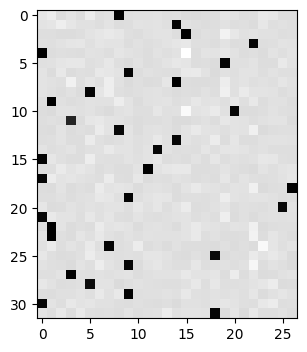

In [32]:
plt.figure(figsize=(4,4))
plt.imshow(dlogits.detach(),cmap='gray')

In [35]:
# Exercise 3: backprop through batchnorm but all in one go
hpreact_fast=bngain*(hprebn-hprebn.mean(0,keepdim=True))/torch.sqrt(hprebn.var(0,keepdim=True)+1e-5)+bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [36]:
# 此处省略一堆数学推导
dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

In [37]:
cmp('hprebn', dhprebn, hprebn)

hprebn          | exact: False | approximate: True  | maxdiff: 1.5133991837501526e-09
